✅ Imagen generada exitosamente y guardada como: secuencia_limpia_atrox.png


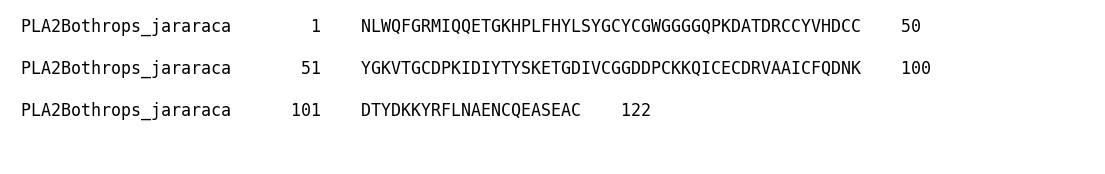

In [ ]:
!pip install biopython
from Bio import SeqIO
import matplotlib.pyplot as plt

def generar_imagen_secuencia(fasta_input, imagen_output, residuos_por_linea=50):
    """
    Lee un archivo FASTA y genera una imagen limpia de la secuencia con numeración.
    """
    # 1. Leer el archivo FASTA usando Biopython
    try:
        record = SeqIO.read(fasta_input, "fasta")
    except ValueError:
        print("Asegúrate de que el archivo FASTA contenga solo una secuencia para este script.")
        return

    seq_name = record.id
    secuencia = str(record.seq)
    longitud = len(secuencia)

    # 2. Formatear el texto línea por línea
    lineas_formateadas = []

    for i in range(0, longitud, residuos_por_linea):
        # Extraer el bloque de la secuencia (por defecto 50 residuos)
        bloque = secuencia[i:i + residuos_por_linea]

        # Calcular numeración (basado en 1)
        inicio = i + 1
        fin = i + len(bloque)

        # Formato de la línea:
        # <25 : Alineado a la izquierda con 25 espacios (Nombre)
        # >4  : Alineado a la derecha con 4 espacios (Número inicial)
        # <4  : Alineado a la izquierda con 4 espacios (Número final)
        linea = f"{seq_name:<25} {inicio:>4}    {bloque}    {fin:<4}"
        lineas_formateadas.append(linea)

    # Unir todas las líneas con un doble salto de línea para dar un buen espaciado vertical
    texto_completo = "\n\n".join(lineas_formateadas)

    # 3. Generar la imagen con Matplotlib
    # Ajustamos la altura de la imagen dependiendo de cuántas líneas tenga la secuencia
    alto_figura = max(2, len(lineas_formateadas) * 0.6)

    fig, ax = plt.subplots(figsize=(14, alto_figura))

    # Añadir el texto usando una fuente 'monospace' (crucial para la alineación)
    ax.text(0.01, 0.95, texto_completo,
            family='monospace',
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    # Ocultar los ejes de la gráfica para que parezca un documento limpio
    ax.axis('off')

    # Guardar la imagen en alta calidad (300 dpi)
    plt.savefig(imagen_output, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"✅ Imagen generada exitosamente y guardada como: {imagen_output}")

    # Mostrar la imagen en el notebook de Colab
    plt.show()

# ==========================================
# CÓDIGO DE PRUEBA (Ejecución en Colab)
# ==========================================

# Creamos un archivo FASTA de prueba simulando tu proteína

with open("PLA2atrox.fasta", "w") as f:
    f.write(fasta_texto)

# Ejecutar el pipeline (le pasamos el archivo recién creado)
generar_imagen_secuencia(
    fasta_input="PLA2atrox.fasta",
    imagen_output="secuencia_limpia.png",
    residuos_por_linea=50  # Aquí configuras que sea de 50 en 50
)